<a href="https://colab.research.google.com/github/warisha-1139/ML-Assignment/blob/main/Linear%26logistic_regression_ass6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1 — Linear Regression
An agricultural research center wants to study the relationship between the amount of fertilizer used and
the crop yield obtained.
Use the following dataset:
Fertilizer (kg/acre) Yield (quintals/acre)
10 12
20 18
30 25
40 31
50 38
60 44
70 50
80 57
90 63
100 70
Task:
Develop a Simple Linear Regression model using Python and scikit-learn to predict crop yield. Your
program should:
1. Load the dataset into a Pandas DataFrame.
2. Perform basic data analysis and check for missing values.
3. Visualize the relationship between fertilizer quantity and yield using a scatter plot.
4. Split the dataset into training and testing sets.
5. Train a Linear Regression model using the training data.
6. Display the coefficient (slope) and intercept of the model.
7. Predict crop yield for the test data.
8. Calculate and display: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared
Error (RMSE), and R² Score.
9. Plot the regression line along with the original data points.
10. Predict the yield for a fertilizer quantity of 65 kg/acre.
11. Explain whether the model provides a good fit based on the obtained evaluation metrics.
Expected Outcome:
A trained Linear Regression model capable of predicting crop yield from fertilizer quantity, along with
appropriate evaluation metrics and graphs.


Dataset:
   Fertilizer  Yield
0          10     12
1          20     18
2          30     25
3          40     31
4          50     38
5          60     44
6          70     50
7          80     57
8          90     63
9         100     70

--- Basic Data Analysis ---

Shape of dataset: (10, 2)

Data types:
Fertilizer    int64
Yield         int64
dtype: object

Statistical Summary:
       Fertilizer      Yield
count   10.000000  10.000000
mean    55.000000  40.800000
std     30.276504  19.452506
min     10.000000  12.000000
25%     32.500000  26.500000
50%     55.000000  41.000000
75%     77.500000  55.250000
max    100.000000  70.000000

Missing values:
Fertilizer    0
Yield         0
dtype: int64


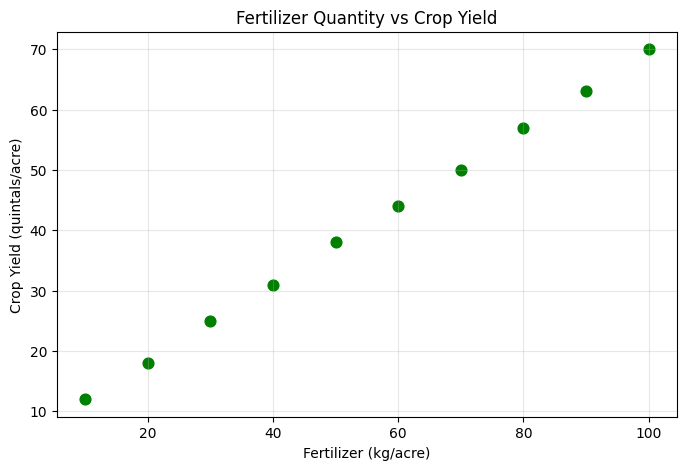


--- Training and Testing Data ---
Training samples: 8
Testing samples: 2

--- Linear Regression Model ---
Slope (Coefficient): 0.6422413793103449
Intercept: 5.551724137931032
Regression Equation: Yield = 5.5517 + (0.6422 × Fertilizer)

--- Test Data Predictions ---
 Fertilizer  Actual Yield  Predicted Yield
         20            18        18.396552
         90            63        63.353448

--- Evaluation Metrics ---
Mean Absolute Error (MAE): 0.375
Mean Squared Error (MSE): 0.14108947681331738
Root Mean Squared Error (RMSE): 0.3756187918799023
R² Score: 0.9997213047371589


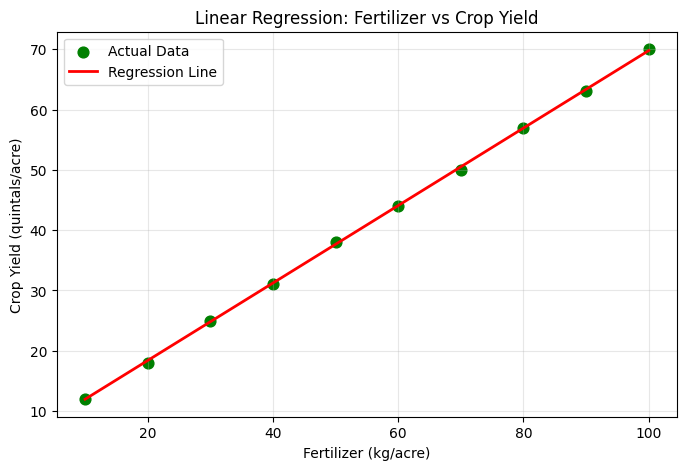


--- Prediction for 65 kg/acre ---
Predicted crop yield for 65 kg/acre fertilizer: 47.30 quintals/acre

--- Model Interpretation ---
The model provides a good fit to the data.
The high R² score indicates that most of the variation
in crop yield is explained by fertilizer quantity.

On average, the model's predictions differ from the actual yield by approximately 0.38 quintals/acre (MAE).


In [1]:
# Question 1 - Linear Regression
# Predicting crop yield from fertilizer quantity

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
# 1. Load the dataset into a Pandas DataFrame
data = {
    "Fertilizer": [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    "Yield":      [12, 18, 25, 31, 38, 44, 50, 57, 63, 70]
}
df = pd.DataFrame(data)
print("Dataset:")
print(df)
# 2. Basic data analysis and missing-value check
print("\n--- Basic Data Analysis ---")
print("\nShape of dataset:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())
# 3. Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Fertilizer"],
    df["Yield"],
    color="green",
    s=60
)

plt.xlabel("Fertilizer (kg/acre)")
plt.ylabel("Crop Yield (quintals/acre)")
plt.title("Fertilizer Quantity vs Crop Yield")
plt.grid(True, alpha=0.3)
plt.show()
# 4. Split dataset into training and testing sets
X = df[["Fertilizer"]]
y = df["Yield"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\n--- Training and Testing Data ---")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
# 5. Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)
# 6. Display coefficient and intercept
slope = model.coef_[0]
intercept = model.intercept_

print("\n--- Linear Regression Model ---")
print("Slope (Coefficient):", slope)
print("Intercept:", intercept)

print(
    f"Regression Equation: Yield = "
    f"{intercept:.4f} + ({slope:.4f} × Fertilizer)"
)



# 7. Predict crop yield for test data


y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Fertilizer": X_test["Fertilizer"].values,
    "Actual Yield": y_test.values,
    "Predicted Yield": y_pred
})

print("\n--- Test Data Predictions ---")
print(results.sort_values("Fertilizer").to_string(index=False))
# 8. Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Evaluation Metrics ---")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)
# 9. Plot regression line with original data
 plt.figure(figsize=(8, 5))
# Original data points
plt.scatter(
    X,
    y,
    color="green",
    s=60,
    label="Actual Data"
)
# Regression line
plt.plot(
    X,
    model.predict(X),
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Fertilizer (kg/acre)")
plt.ylabel("Crop Yield (quintals/acre)")
plt.title("Linear Regression: Fertilizer vs Crop Yield")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# 10. Predict yield for 65 kg/acre fertilizer
 fertilizer_value = pd.DataFrame({
    "Fertilizer": [65]
})

predicted_yield = model.predict(fertilizer_value)[0]

print("\n--- Prediction for 65 kg/acre ---")
print(
    f"Predicted crop yield for 65 kg/acre fertilizer: "
    f"{predicted_yield:.2f} quintals/acre"
)
# 11. Model interpretation
 print("\n--- Model Interpretation ---")

if r2 >= 0.8:
    print("The model provides a good fit to the data.")
    print("The high R² score indicates that most of the variation")
    print("in crop yield is explained by fertilizer quantity.")
else:
    print("The model may not provide a strong fit to the data.")

print(
    f"\nOn average, the model's predictions differ from the actual "
    f"yield by approximately {mae:.2f} quintals/acre (MAE)."
)


Question 2 — Multiple Linear Regression
An automobile company wants to predict the fuel efficiency (mileage) of cars based on engine size and car
weight.
Use the following dataset:
Engine Size (L) Weight (kg) Mileage (km/l)
1.0 900 22.5
1.2 950 20.8
1.5 1050 18.2
1.8 1150 16.0
2.0 1250 14.5
2.2 1300 13.2
2.5 1400 12.0
3.0 1550 10.1
3.5 1650 8.8
4.0 1800 7.5
Task:
Develop a Multiple Linear Regression model using Python and scikit-learn to predict mileage from engine
size and weight. Your program should:
1. Load the dataset into a Pandas DataFrame.
2. Perform basic data analysis and check for missing values.
3. Visualize the relationship between each independent variable and mileage using scatter plots.
4. Split the dataset into training and testing sets.
5. Train a Multiple Linear Regression model using engine size and weight as predictors.
6. Display the coefficients and intercept of the model, and interpret their meaning.
7. Predict mileage values for the test data.
8. Calculate and display: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared
Error (RMSE), and R² Score.
9. Plot actual mileage versus predicted mileage.
10. Predict the mileage for a car with an engine size of 2.8 L and weight of 1450 kg.
11. Explain whether the model provides a good fit and which feature has a greater influence on
mileage.
Expected Outcome:
A trained Multiple Linear Regression model capable of predicting car mileage from engine size and
weight, along with appropriate evaluation metrics and graphs.


Dataset:
   Engine_Size  Weight  Mileage
0          1.0     900     22.5
1          1.2     950     20.8
2          1.5    1050     18.2
3          1.8    1150     16.0
4          2.0    1250     14.5
5          2.2    1300     13.2
6          2.5    1400     12.0
7          3.0    1550     10.1
8          3.5    1650      8.8
9          4.0    1800      7.5

--- Basic Data Analysis ---

Shape of dataset:
(10, 3)

Data types:
Engine_Size    float64
Weight           int64
Mileage        float64
dtype: object

Statistical Summary:
       Engine_Size       Weight    Mileage
count    10.000000    10.000000  10.000000
mean      2.270000  1300.000000  14.360000
std       0.985506   300.924501   5.035695
min       1.000000   900.000000   7.500000
25%       1.575000  1075.000000  10.575000
50%       2.100000  1275.000000  13.850000
75%       2.875000  1512.500000  17.650000
max       4.000000  1800.000000  22.500000

Missing values:
Engine_Size    0
Weight         0
Mileage        0
dtype: int

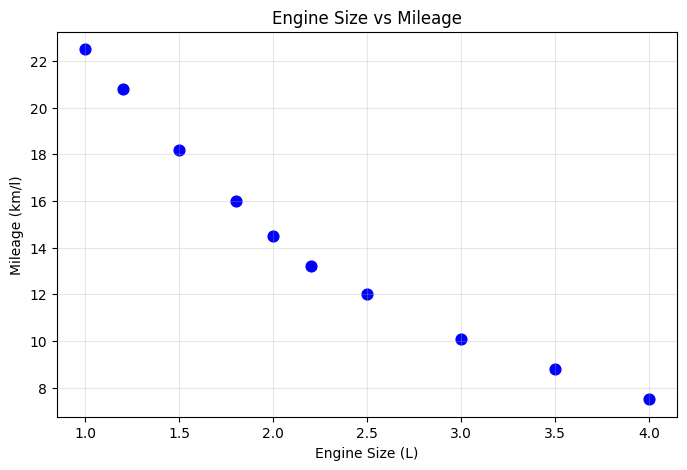

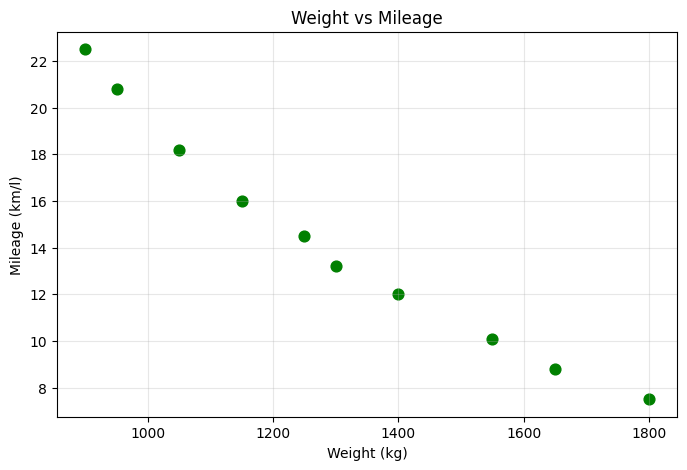


--- Training and Testing Data ---
Training samples: 8
Testing samples: 2

--- Multiple Linear Regression Model ---
Intercept: 52.706154628687685
Coefficient for Engine Size: 8.821973550356054
Coefficient for Weight: -0.04485045778229908

Regression Equation:
Mileage = 52.7062 + (8.8220 × Engine Size) + (-0.0449 × Weight)

--- Coefficient Interpretation ---
Engine Size coefficient = 8.8220
Keeping vehicle weight constant, increasing engine size by 1 L changes the predicted mileage by approximately 8.8220 km/l.

Weight coefficient = -0.0449
Keeping engine size constant, increasing vehicle weight by 1 kg changes the predicted mileage by approximately -0.0449 km/l.

--- Test Data Predictions ---
 Engine Size  Weight  Actual Mileage  Predicted Mileage
         1.2     950            20.8          20.684588
         3.5    1650             8.8           9.579807

--- Evaluation Metrics ---
Mean Absolute Error (MAE): 0.4476
Mean Squared Error (MSE): 0.3107
Root Mean Squared Error (RMSE): 0.5

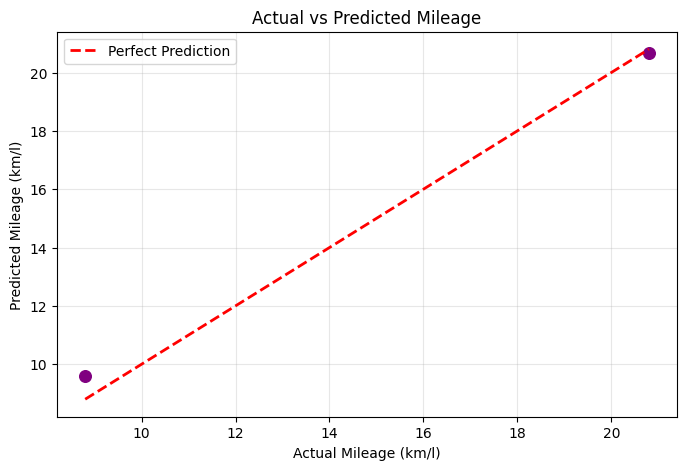


--- New Car Prediction ---
Engine Size: 2.8 L
Weight: 1450 kg
Predicted Mileage: 12.37 km/l

--- Model Interpretation ---
The model provides a good fit because the R² score is high and the prediction errors are relatively small.

Both engine size and weight have a negative relationship with mileage.
A larger negative coefficient indicates a greater change in predicted mileage per unit increase, but the raw coefficients should not be directly compared because Engine Size is measured in litres while Weight is measured in kilograms.


In [2]:
# Question 2 - Multiple Linear Regression
# Predicting car mileage from engine size and weight

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
# 1. Load the dataset into a Pandas DataFrame
 data = {
    "Engine_Size": [1.0, 1.2, 1.5, 1.8, 2.0, 2.2, 2.5, 3.0, 3.5, 4.0],
    "Weight":      [900, 950, 1050, 1150, 1250, 1300, 1400, 1550, 1650, 1800],
    "Mileage":     [22.5, 20.8, 18.2, 16.0, 14.5, 13.2, 12.0, 10.1, 8.8, 7.5]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# 2. Basic data analysis and missing-value check
 print("\n--- Basic Data Analysis ---")

print("\nShape of dataset:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())
# 3. Visualize independent variables vs mileage
# Engine Size vs Mileage
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Engine_Size"],
    df["Mileage"],
    color="blue",
    s=60
)

plt.xlabel("Engine Size (L)")
plt.ylabel("Mileage (km/l)")
plt.title("Engine Size vs Mileage")
plt.grid(True, alpha=0.3)
plt.show()
# Weight vs Mileage
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Weight"],
    df["Mileage"],
    color="green",
    s=60
)

plt.xlabel("Weight (kg)")
plt.ylabel("Mileage (km/l)")
plt.title("Weight vs Mileage")
plt.grid(True, alpha=0.3)
plt.show()
# 4. Split dataset into training and testing sets
X = df[["Engine_Size", "Weight"]]
y = df["Mileage"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\n--- Training and Testing Data ---")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# 5. Train Multiple Linear Regression model
 model = LinearRegression()
 model.fit(X_train, y_train)
# 6. Display coefficients and intercept
 intercept = model.intercept_
engine_coefficient = model.coef_[0]
weight_coefficient = model.coef_[1]

print("\n--- Multiple Linear Regression Model ---")

print("Intercept:", intercept)

print("Coefficient for Engine Size:", engine_coefficient)

print("Coefficient for Weight:", weight_coefficient)

print(
    f"\nRegression Equation:\n"
    f"Mileage = {intercept:.4f} "
    f"+ ({engine_coefficient:.4f} × Engine Size) "
    f"+ ({weight_coefficient:.4f} × Weight)"
)
# Interpretation of coefficients
print("\n--- Coefficient Interpretation ---")

print(
    f"Engine Size coefficient = {engine_coefficient:.4f}"
)

print(
    "Keeping vehicle weight constant, increasing engine size "
    "by 1 L changes the predicted mileage by approximately "
    f"{engine_coefficient:.4f} km/l."
)

print(
    f"\nWeight coefficient = {weight_coefficient:.4f}"
)

print(
    "Keeping engine size constant, increasing vehicle weight "
    "by 1 kg changes the predicted mileage by approximately "
    f"{weight_coefficient:.4f} km/l."
)

# 7. Predict mileage for test data
 y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Engine Size": X_test["Engine_Size"].values,
    "Weight": X_test["Weight"].values,
    "Actual Mileage": y_test.values,
    "Predicted Mileage": y_pred
})

print("\n--- Test Data Predictions ---")

print(
    results.sort_values("Engine Size").to_string(index=False)
)

# 8. Calculate evaluation metrics
 mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n--- Evaluation Metrics ---")

print(f"Mean Absolute Error (MAE): {mae:.4f}")

print(f"Mean Squared Error (MSE): {mse:.4f}")

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

print(f"R² Score: {r2:.4f}")
# 9. Plot actual mileage vs predicted mileage
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    color="purple",
    s=70
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Mileage (km/l)")
plt.ylabel("Predicted Mileage (km/l)")
plt.title("Actual vs Predicted Mileage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 10. Predict mileage for a new car
 new_car = pd.DataFrame({
    "Engine_Size": [2.8],
    "Weight": [1450]
})

predicted_mileage = model.predict(new_car)[0]

print("\n--- New Car Prediction ---")

print(
    f"Engine Size: 2.8 L"
)

print(
    f"Weight: 1450 kg"
)

print(
    f"Predicted Mileage: {predicted_mileage:.2f} km/l"
)

# 11. Model evaluation and feature influence
 print("\n--- Model Interpretation ---")

if r2 >= 0.80:
    print(
        "The model provides a good fit because the R² score "
        "is high and the prediction errors are relatively small."
    )
else:
    print(
        "The model may not provide a strong fit because the "
        "R² score is relatively low."
    )

print(
    "\nBoth engine size and weight have a negative relationship "
    "with mileage."
)

print(
    "A larger negative coefficient indicates a greater change "
    "in predicted mileage per unit increase, but the raw "
    "coefficients should not be directly compared because "
    "Engine Size is measured in litres while Weight is measured "
    "in kilograms."
)


Question 3 — Logistic Regression
A bank wants to predict whether a customer will default on a loan based on their annual income and credit
score.
Use the following dataset:
Income (■ Lakhs) Credit Score Defaulted (1=Yes, 0=No)
3.5 580 1
4.2 610 1
5.0 650 1
6.1 680 0
7.0 700 0
8.2 720 0
3.0 560 1
9.5 750 0
5.5 630 1
10.0 770 0
4.8 600 1
8.8 740 0
Task:
Develop a Logistic Regression model using Python and scikit-learn to predict loan default. Your program
should:
1. Load the dataset into a Pandas DataFrame.
2. Perform basic data analysis and check for missing values and class balance.
3. Visualize the relationship between income, credit score, and default status using a suitable scatter
plot.
4. Split the dataset into training and testing sets.
5. Train a Logistic Regression model using income and credit score as features.
6. Display the model coefficients and intercept, and interpret their meaning.
7. Predict the default outcome for the test data.
8. Generate and display the confusion matrix.
9. Calculate and display: Accuracy, Precision, Recall, and F1-Score.
10. Plot the ROC curve and calculate the AUC score.
11. Predict whether a customer with an income of ■6.5 Lakhs and a credit score of 660 will default.
12. Explain the model's performance based on the obtained evaluation metrics.
Expected Outcome:
A trained Logistic Regression model capable of classifying customers as likely or unlikely to default, along
with appropriate evaluation metrics and graphs.

Dataset:
    Income_Lakhs  Credit_Score  Defaulted
0            3.5           580          1
1            4.2           610          1
2            5.0           650          1
3            6.1           680          0
4            7.0           700          0
5            8.2           720          0
6            3.0           560          1
7            9.5           750          0
8            5.5           630          1
9           10.0           770          0
10           4.8           600          1
11           8.8           740          0

--- Basic Data Analysis ---

Shape of dataset:
(12, 3)

Data types:
Income_Lakhs    float64
Credit_Score      int64
Defaulted         int64
dtype: object

Statistical Summary:
       Income_Lakhs  Credit_Score  Defaulted
count     12.000000     12.000000  12.000000
mean       6.300000    665.833333   0.500000
std        2.374868     70.897921   0.522233
min        3.000000    560.000000   0.000000
25%        4.650000    607.500000   0.00000

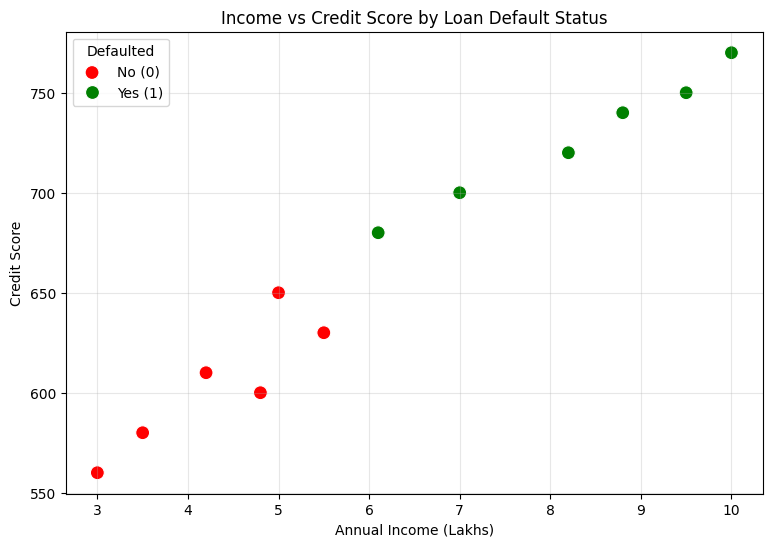


--- Training and Testing Data ---
Training samples: 9
Testing samples: 3

--- Logistic Regression Model ---
Intercept: 202.88326532863113
Income coefficient: -0.011187116536040606
Credit Score coefficient: -0.30499595221029063

Logistic Regression Equation:
log(p / (1-p)) = 202.8833 + (-0.0112 × Income) + (-0.3050 × Credit Score)

--- Coefficient Interpretation ---
Income coefficient = -0.0112
A positive coefficient means that increasing income increases the log-odds of default, while a negative coefficient means that increasing income decreases the log-odds of default.

Credit Score coefficient = -0.3050
A negative coefficient means that customers with higher credit scores are less likely to default, while keeping income constant.

--- Test Data Predictions ---
 Income  Credit Score  Actual Default  Predicted Default  Default Probability
    5.5           630               1                  1         9.999769e-01
    9.5           750               0                  0         5.264

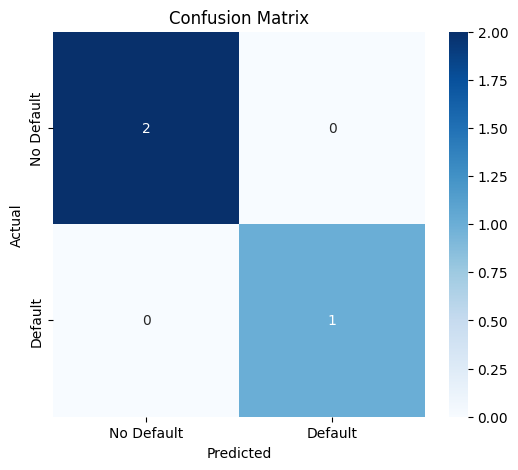


--- Classification Metrics ---
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

--- ROC / AUC ---
AUC Score: 1.0000


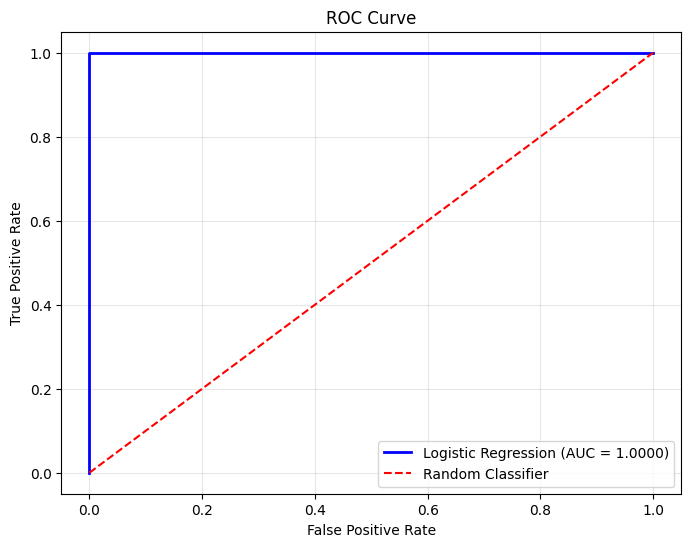


--- New Customer Prediction ---
Income: ₹6.5 Lakhs
Credit Score: 660
Probability of Default: 0.8195
Prediction: Customer is likely to DEFAULT.

--- Overall Model Performance ---
Accuracy  = 1.0000
Precision = 1.0000
Recall    = 1.0000
F1-Score  = 1.0000
AUC       = 1.0000

The model's performance should be interpreted carefully because the dataset contains only 12 observations. Therefore, the test-set metrics can change substantially with a different train/test split.


In [3]:
# Question 3 - Logistic Regression
# Predicting Loan Default

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)
# 1. Load the dataset into a Pandas DataFrame
data = {
    "Income_Lakhs": [
        3.5, 4.2, 5.0, 6.1, 7.0, 8.2,
        3.0, 9.5, 5.5, 10.0, 4.8, 8.8
    ],

    "Credit_Score": [
        580, 610, 650, 680, 700, 720,
        560, 750, 630, 770, 600, 740
    ],

    "Defaulted": [
        1, 1, 1, 0, 0, 0,
        1, 0, 1, 0, 1, 0
    ]
}

df = pd.DataFrame(data)
print("Dataset:")
print(df)
# 2. Basic data analysis, missing values and class balance
print("\n--- Basic Data Analysis ---")
print("\nShape of dataset:")
print(df.shape)
print("\nData types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass Balance:")
print(df["Defaulted"].value_counts())

print("\nClass Balance in Percentage:")
print(
    df["Defaulted"].value_counts(normalize=True) * 100
)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Income_Lakhs",
    y="Credit_Score",
    hue="Defaulted",
    palette={0: "green", 1: "red"},
    s=100
)

plt.xlabel("Annual Income (Lakhs)")
plt.ylabel("Credit Score")
plt.title("Income vs Credit Score by Loan Default Status")

plt.legend(
    title="Defaulted",
    labels=["No (0)", "Yes (1)"]
)

plt.grid(True, alpha=0.3)
plt.show()
# 4. Split dataset into training and testing sets
X = df[["Income_Lakhs", "Credit_Score"]]
y = df["Defaulted"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\n--- Training and Testing Data ---")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
# 5. Train Logistic Regression model
model = LogisticRegression()

model.fit(X_train, y_train)

# 6. Display coefficients and intercept
intercept = model.intercept_[0]
income_coefficient = model.coef_[0][0]
credit_coefficient = model.coef_[0][1]

print("\n--- Logistic Regression Model ---")

print("Intercept:", intercept)

print("Income coefficient:", income_coefficient)

print("Credit Score coefficient:", credit_coefficient)

print(
    "\nLogistic Regression Equation:"
)

print(
    f"log(p / (1-p)) = {intercept:.4f} "
    f"+ ({income_coefficient:.4f} × Income) "
    f"+ ({credit_coefficient:.4f} × Credit Score)"
)
# Interpret coefficients
print("\n--- Coefficient Interpretation ---")

print(
    f"Income coefficient = {income_coefficient:.4f}"
)

print(
    "A positive coefficient means that increasing income "
    "increases the log-odds of default, while a negative "
    "coefficient means that increasing income decreases "
    "the log-odds of default."
)

print(
    f"\nCredit Score coefficient = {credit_coefficient:.4f}"
)

print(
    "A negative coefficient means that customers with higher "
    "credit scores are less likely to default, while keeping "
    "income constant."
)
# 7. Predict default outcome for test data
y_pred = model.predict(X_test)

# Probability of default
y_prob = model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Income": X_test["Income_Lakhs"].values,
    "Credit Score": X_test["Credit_Score"].values,
    "Actual Default": y_test.values,
    "Predicted Default": y_pred,
    "Default Probability": y_prob
})

print("\n--- Test Data Predictions ---")

print(
    results.to_string(index=False)
)
# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n--- Confusion Matrix ---")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
# 9. Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)
print("\n--- Classification Metrics ---")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# 10. ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print("\n--- ROC / AUC ---")

print(f"AUC Score: {auc_score:.4f}")

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    color="blue",
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_score:.4f})"
)
# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    color="red",
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 11. Predict for new customer
new_customer = pd.DataFrame({
    "Income_Lakhs": [6.5],
    "Credit_Score": [660]
})

new_probability = model.predict_proba(
    new_customer
)[0][1]

new_prediction = model.predict(
    new_customer
)[0]

print("\n--- New Customer Prediction ---")

print("Income: ₹6.5 Lakhs")

print("Credit Score: 660")

print(
    f"Probability of Default: "
    f"{new_probability:.4f}"
)

if new_prediction == 1:
    print("Prediction: Customer is likely to DEFAULT.")
else:
    print("Prediction: Customer is NOT likely to DEFAULT.")
# 12. Overall model interpretation
 print("\n--- Overall Model Performance ---")

print(
    f"Accuracy  = {accuracy:.4f}"
)

print(
    f"Precision = {precision:.4f}"
)

print(
    f"Recall    = {recall:.4f}"
)

print(
    f"F1-Score  = {f1:.4f}"
)

print(
    f"AUC       = {auc_score:.4f}"
)

print(
    "\nThe model's performance should be interpreted carefully "
    "because the dataset contains only 12 observations. "
    "Therefore, the test-set metrics can change substantially "
    "with a different train/test split."
)
